# Solutions · 00 · Python for rheology data

Worked solutions to the exercises of [notebook 00](../notebooks/00_python_for_rheology_data.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engrheo import datasets, geometry
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

In [2]:
df = pd.read_csv(datasets.path("xanthan_flow_curve.csv"), comment="#")
rate, eta = df.shear_rate_1_s.to_numpy(), df.viscosity_Pa_s.to_numpy()

## Exercise 1

The rheometer's minimum reliable torque is 1 µN·m. What is the lowest shear stress this cone (R = 25 mm)
   can measure? Draw the corresponding "low-torque limit" line $\eta_{min} = \tau_{min}/\dot\gamma$ on the viscosity plot.
   Are all the data safely above it?

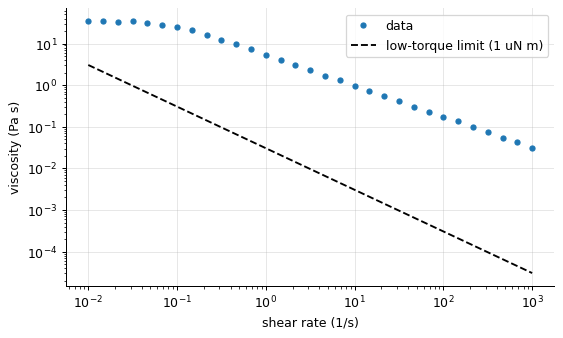

lowest measurable stress 30.6 mPa; smallest margin above the limit: factor 11 (at 0.01 1/s)


In [3]:
tau_min, _ = geometry.cone_plate(1e-6, 1.0, R=0.025, theta=np.radians(1.0))
eta_min = tau_min / rate
plt.loglog(rate, eta, "o", ms=4, label="data"); plt.loglog(rate, eta_min, "k--", label="low-torque limit (1 uN m)")
plt.xlabel("shear rate (1/s)"); plt.ylabel("viscosity (Pa s)"); plt.legend(); plt.show()
print(f"lowest measurable stress {tau_min*1e3:.1f} mPa; smallest margin above the limit: factor {np.min(eta / eta_min):.0f} "
      f"(at {rate[np.argmin(eta / eta_min)]:g} 1/s)")

The low-torque limit is a straight line of slope $-1$ on the viscosity plot (constant minimum stress divided by
the rate). Every point lies well above it, so the whole flow curve is trustworthy. The margin is smallest
at the lowest shear rates, where both the stress and the torque are smallest - which is where low-viscosity
samples usually hit the limit first.

## Exercise 2

Read the file again with `np.loadtxt` instead of pandas (hint: `delimiter`, `comments`, `skiprows`).
   When is each tool more convenient?

In [4]:
arr = np.loadtxt(datasets.path("xanthan_flow_curve.csv"), delimiter=",", skiprows=3)   # 2 comment lines + header
print(arr.shape, arr[:2])
print("same numbers as pandas:", np.allclose(arr, df.to_numpy()))

(31, 4) [[1.0000e-02 3.4265e-01 3.4265e+01 1.1213e-05]
 [1.4678e-02 5.1033e-01 3.4768e+01 1.6700e-05]]
same numbers as pandas: True


`np.loadtxt` returns a plain array: fast and simple for purely numeric files, but you must count the lines
to skip and remember which column is which. pandas keeps the column names, handles comment lines, mixed
types and missing values - more convenient for real exports (notebook 17).

## Exercise 3

**Implement it yourself:** write `loglog_interp(x0, x, y)` that interpolates linearly in log-log coordinates, and check it against the notebook's result at 50 1/s.

In [5]:
def loglog_interp(x0, x, y):
    return np.exp(np.interp(np.log(x0), np.log(x), np.log(y)))
print(f"viscosity at 50 1/s: {loglog_interp(50.0, rate, eta):.4f} Pa s")

viscosity at 50 1/s: 0.2895 Pa s


Interpolating straight lines between the logarithms reproduces the notebook's log-log value, which follows a
power-law curve between neighbouring points instead of a straight line on linear axes.